# Khipus.ai — Estadística Aplicada con Python
## Módulo 2 · Clase 2 — Repaso relámpago de la Clase 1

**Docente:** Walter J. Méndez · UTEPSA / Khipus.ai

---

### Por qué existe este notebook

La clase pasada nos quedamos en la parte que **nadie enseña** y que es la que más se paga:
averiguar si el dato sirve. Descubrimos que `Offer price` faltaba en el 82% de las filas, que había
24 anuncios duplicados y que **la mitad de las "ofertas" eran más caras** que el precio normal.

Eso no fue tiempo perdido: ese es el trabajo real. Hoy lo cobramos.

En los próximos 15 minutos recuperamos las **cuatro herramientas** que quedaron pendientes. No son
las nueve del temario: son exactamente las cuatro que vamos a usar hoy, y ninguna más.

| Herramienta | Responde | Dónde vuelve hoy |
|---|---|---|
| **Media y mediana** | ¿Alrededor de qué valor están los datos? | En casi todo el notebook de hoy |
| **Desviación estándar** | ¿Qué tan dispersos están? | Bloque D — la ley σ/√n |
| **Cuartiles y percentiles** | ¿Qué posición ocupa un valor? | Bloque F — el intervalo de confianza **es** percentiles |
| **Histograma y asimetría** | ¿Qué **forma** tiene la distribución? | Bloque D — el corazón de la clase de hoy |

Y con esas cuatro respondemos, por fin, la pregunta que dejamos abierta el sábado pasado:

> ## ¿Cuánto cuesta *realmente* un Airbnb?

In [9]:
import os                                      # para chequear si el CSV local existe
import numpy as np                             # operaciones numéricas
import pandas as pd                            # tablas de datos (DataFrame)
import seaborn as sns                          # gráficos estadísticos, sobre matplotlib
import matplotlib.pyplot as plt                # motor de gráficos base

sns.set_style("whitegrid")                     # mismo estilo visual que el notebook de hoy

# El archivo vive en la carpeta de la Clase 1; si no está, se baja del repo de Khipus.
_CANDIDATOS = [
    "../../clase1-descriptiva/datos/airnb.csv",   # ruta desde la carpeta de la Clase 2
    "../datos/airnb.csv",                          # por si lo copiaste acá al lado
]
_URL = "https://raw.githubusercontent.com/Khipus-ai/Applied_Statistics_Python/main/1%20Descriptive_Statistics/airnb.csv"

_origen = next((p for p in _CANDIDATOS if os.path.exists(p)), _URL)
df = pd.read_csv(_origen)                      # el MISMO archivo del sábado pasado

print(f"Anuncios cargados: {df.shape[0]}")
print(f"Origen: {'carpeta local' if _origen != _URL else 'repositorio de Khipus (GitHub)'}")

Anuncios cargados: 538
Origen: repositorio de Khipus (GitHub)


## Primero, cerramos lo que quedó a medias

El sábado pasado estábamos en el medio de esto cuando se nos acabó el tiempo: el archivo trae solo
**dos** columnas numéricas, y otras tres estaban **escondidas dentro de texto**.

`"4 beds"` es texto, no un número. `"4.85 (531)"` son en realidad dos datos pegados. Con
`.str.split(" ")` los partimos por el espacio y nos quedamos con el pedazo que nos interesa.

Van las tres en tres líneas — el paso a paso está en el notebook de la Clase 1, sección 3.

In [10]:
# Las camas: "4 beds" -> partimos por el espacio, tomamos el primer pedazo, lo volvemos número
df["camas"] = df["Number of bed"].str.split(" ").str[0].astype(int)

# El rating: "4.85 (531)" -> el primer pedazo. Ojo: 10 anuncios dicen "New" en vez de un número,
# y por eso usamos pd.to_numeric con errors="coerce", que los deja vacíos en vez de reventar.
df["rating"] = pd.to_numeric(df["Review and rating"].str.split(" ").str[0], errors="coerce")

# Las reseñas: el número entre paréntesis
df["n_resenas"] = df["Review and rating"].str.extract(r"\((\d+)\)").astype(float)

precio = df["Price(in dollar)"]                # la columna protagonista del repaso

print(f"De 2 columnas numéricas pasamos a 5. Ratings válidos: {df['rating'].notna().sum()} de {len(df)}")
df[["Price(in dollar)", "camas", "rating", "n_resenas"]].head()

De 2 columnas numéricas pasamos a 5. Ratings válidos: 526 de 538


,Price(in dollar),camas,rating,n_resenas
0,306,4,4.85,531.0
1,485,4,4.77,146.0
2,119,4,4.91,515.0
3,192,5,4.94,88.0
4,381,2,5.00,48.0


---

# 1. La tabla que hace todo de una vez: `.describe()`

👨‍🏫 Tenemos 538 precios. Nadie puede mirar 538 números y sacar una conclusión: necesitamos
**resumirlos**. `describe()` calcula de un saque todo lo que la clase pasada íbamos a ver medida por
medida.

In [18]:
df[["Price(in dollar)", "camas", "rating", "n_resenas"]].describe().round(2)

,Price(in dollar),camas,rating,n_resenas
count,538.00,538.00,526.00,526.00
mean,175.26,2.51,4.86,176.94
std,136.36,1.24,0.14,176.82
min,16.00,1.00,4.00,3.00
25%,90.00,2.00,4.81,46.25
50%,138.00,2.00,4.89,124.50
75%,222.00,3.00,4.96,241.75
max,955.00,7.00,5.00,1239.00


## 👨‍🏫 Cómo se lee esta tabla

Fijate solo en la columna del precio. Cada fila es un concepto de la clase pasada:

| Fila | Cómo se llama | Qué dice del precio |
|---|---|---|
| `count` | cantidad de datos | 538 anuncios con precio |
| `mean` | **media** (el promedio) | $175.26 |
| `std` | **desviación estándar** | $136.36 — el "cuánto se alejan del promedio", en dólares |
| `min` / `max` | el rango | de $16 a $955 |
| `25%` | **primer cuartil (Q1)** | el 25% de los anuncios cuesta menos de $90 |
| `50%` | **mediana** (= segundo cuartil) | la mitad cuesta menos de $138 |
| `75%` | **tercer cuartil (Q3)** | el 75% cuesta menos de $222 |

💡 Los tres porcentajes de abajo son **percentiles**: el percentil 25 es el valor que deja el 25% de
los datos por debajo. Guardá esa idea — después del descanso vamos a construir un intervalo de
confianza, y va a resultar que **un intervalo de confianza no es otra cosa que dos percentiles**.

## 🤨 Un momento. ¿Cuál es el precio de un Airbnb, entonces?

- Si te digo **$175** (la media), no estoy mintiendo.
- Si te digo **$138** (la mediana), tampoco.

Son **$37 de diferencia**: la media es un 27% más alta. En un viaje de 7 noches, eso es $259 — un
pasaje. **¿Cuál de los dos hay que reportar?** Para contestarlo hay que entender por qué se separan.

---

# 2. 🎬 El experimento del penthouse fantasma

Vamos a hacer algo que parece una tontería y es la demostración más importante de la clase pasada.

Imaginemos que aparece **un solo anuncio más**: un penthouse en Dubái a **$50.000 la noche**.
Un anuncio en 538. Menos del 0.2% del dataset.

🤔 **Predicción — escribilo en el chat antes de que ejecute:**

1. ¿Cuánto creés que va a subir la **media**?
2. ¿Cuánto creés que va a subir la **mediana**?

In [12]:
# Agregamos UN solo anuncio de $50.000 al final de la columna de precios
precio_con_penthouse = pd.concat([precio, pd.Series([50000])], ignore_index=True)

print("                    ANTES        DESPUÉS      CAMBIO")
print("                 ---------    ----------   ----------")
print(f"Media            ${precio.mean():>8.2f}    ${precio_con_penthouse.mean():>8.2f}    ${precio_con_penthouse.mean() - precio.mean():>+8.2f}")
print(f"Mediana          ${precio.median():>8.2f}    ${precio_con_penthouse.median():>8.2f}    ${precio_con_penthouse.median() - precio.median():>+8.2f}")

                    ANTES        DESPUÉS      CAMBIO
                 ---------    ----------   ----------
Media            $  175.26    $  267.70    $  +92.44
Mediana          $  138.00    $  138.00    $   +0.00


## 💥 Un solo dato movió la media $92. La mediana no se movió ni un centavo.

La media es el **punto de equilibrio de un subibaja**: si ponés un elefante en una punta, todo el
subibaja se inclina. La mediana es **el que está parado justo en la mitad de la fila**: no le importa
si el último de la fila es rico o millonario, sigue siendo el mismo.

## ✅ La respuesta a la pregunta que quedó abierta

> ### ¿Cuánto cuesta realmente un Airbnb?
> **Unos $138 la noche** (mediana), no $175 (media).
>
> 💡 Cuando los datos tienen valores extremos hacia un lado, **la mediana describe mejor al típico**.

⚠️ Y no lo archives como anécdota de la clase pasada: **hoy vuelve**. Sobre el final vamos a comparar
cuánto ganan los desarrolladores que usan IA contra los que todavía no, y vamos a medir esa
diferencia con la media. Cuando la midamos con la **mediana**, el resultado cambia de signo.

---

# 3. La forma: el histograma

👨‍🏫 La media y la mediana dan **un** número. Pero un número no muestra cómo están repartidos los
datos. Para eso está el **histograma**: parte el rango de precios en cajones y cuenta cuántos
anuncios caen en cada uno.

Es el gráfico más importante de las tres clases del módulo. Hoy lo vamos a usar cuatro veces.

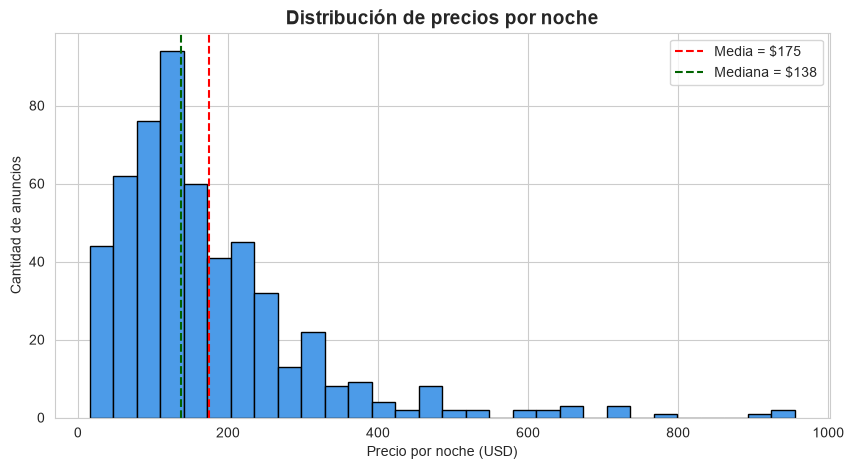

Asimetría (skew): 2.34


In [22]:
plt.figure(figsize=(10, 5)) #Tamaño de la figura

plt.hist(precio, bins=30, edgecolor="black", color="#4C9BE8") #Crea el histograma de los precios

# Marcamos media y mediana para verlas en su contexto
plt.axvline(precio.mean(),   color="red",       linestyle="--", linewidth=1.5, label=f"Media = ${precio.mean():.0f}")
plt.axvline(precio.median(), color="darkgreen", linestyle="--", linewidth=1.5, label=f"Mediana = ${precio.median():.0f}")

plt.title("Distribución de precios por noche", fontsize=14, fontweight="bold")
plt.xlabel("Precio por noche (USD)")
plt.ylabel("Cantidad de anuncios")
plt.legend()
plt.show()

print(f"Asimetría (skew): {precio.skew():.2f}")

## 👨‍🏫 Ahí está, en una imagen, toda la clase pasada

- La montaña está **amontonada a la izquierda** y arrastra una **cola larga hacia la derecha**.
- La línea verde (mediana) está **dentro** de la montaña, donde está la gente.
- La línea roja (media) está **a la derecha de la verde**, tironeada por la cola.

Eso tiene nombre: **asimetría** (o *sesgo*). El número que la mide es `skew`, y acá vale **2.34**.

| `skew` | Qué significa | Qué reportar |
|---|---|---|
| ≈ 0 | simétrica, la campana clásica | media |
| > 1 | cola larga a la derecha | **mediana** |
| < −1 | cola larga a la izquierda | **mediana** |

💡 **Quedate con la palabra "forma".** Dentro de un rato vamos a hacer un experimento en el que una
distribución igual de deforme que ésta **se convierte en una campana** delante de sus ojos. Si no
tuvieran esta imagen en la cabeza, ese momento no significaría nada.

---

# 4. ¿Y si le dibujamos una campana encima?

👨‍🏫 La **distribución normal** —la famosa campana de Gauss— es la forma que más aparece en los
libros de estadística. Vamos a dibujar la campana que *tendría* estos datos si fueran normales,
usando su misma media ($175) y su misma desviación estándar ($136), y la superponemos sobre el
histograma real.

🤔 **Predicción antes de ejecutar:** ¿la campana va a calzar sobre la montaña azul, sí o no?

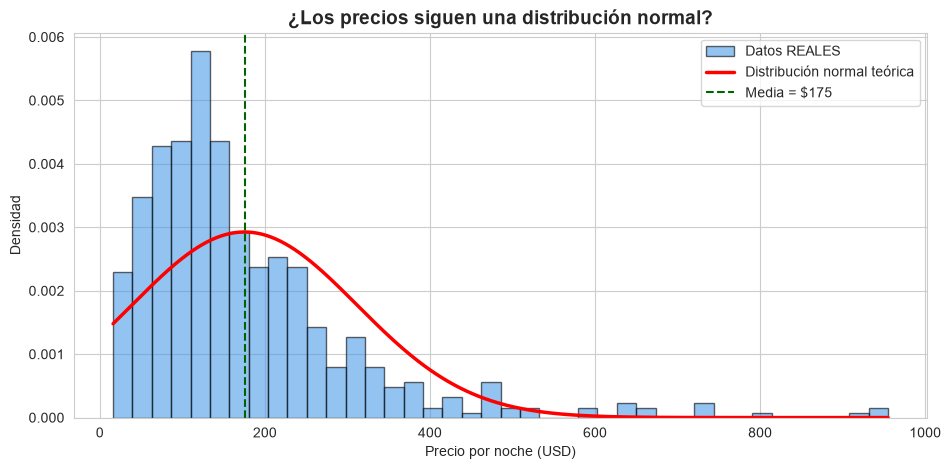

In [14]:
media = precio.mean()
desviacion = precio.std()

# La campana normal teórica con esa misma media y esa misma desviación
x = np.linspace(precio.min(), precio.max(), 500)
y_normal = (1 / (desviacion * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / desviacion) ** 2)

plt.figure(figsize=(11, 5))

# Histograma real, normalizado para poder compararlo con la curva
plt.hist(precio, bins=40, density=True, alpha=0.6,
         color="#4C9BE8", edgecolor="black", label="Datos REALES")

plt.plot(x, y_normal, color="red", linewidth=2.5, label="Distribución normal teórica")
plt.axvline(media, color="darkgreen", linestyle="--", label=f"Media = ${media:.0f}")

plt.title("¿Los precios siguen una distribución normal?", fontsize=14, fontweight="bold")
plt.xlabel("Precio por noche (USD)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

## ⚠️ No. Y no se parecen en nada.

- La campana roja es **simétrica**; los datos azules están volcados a la izquierda.
- La campana predice **precios negativos** — mirá cómo se estira a la izquierda del cero. Un Airbnb
  a −$50 la noche te pagaría por dormir ahí. No existe.
- Subestima cuántos anuncios baratos hay y no captura la cola larga.

### 👨‍🏫 Y acá está el puente exacto hacia la clase de hoy

> La **estadística inferencial** —lo que empezamos en cinco minutos— apoya buena parte de su
> maquinaria clásica en el supuesto de que los datos son normales.
>
> Pero nuestros datos **no son normales**. Ninguno de los dos datasets lo es.
>
> ### ¿Entonces cómo hago matemática seria con datos que no son normales?

Esa pregunta es, literalmente, la primera mitad de la clase de hoy. Y la respuesta no es una fórmula:
es una idea que vamos a **ver funcionar** antes de nombrarla.

---

## 📌 Lo que te llevás de estos 15 minutos

| Concepto | En Python | Lo usás hoy en |
|---|---|---|
| Media | `.mean()` | todo el notebook |
| Mediana | `.median()` | el cierre — donde da vuelta la conclusión |
| Desviación estándar | `.std()` | Bloque D |
| Cuartiles y percentiles | `.quantile()` · `np.percentile()` | Bloque F — el intervalo de confianza |
| Forma y asimetría | histograma · `.skew()` | Bloque D — el corazón de la clase |
| Resumen de todo | `.describe()` | cuando te toque un dataset nuevo |

💡 El resto de la Clase 1 —boxplots, outliers, `groupby`, correlación— sigue en el notebook
`01a_Estadistica_Descriptiva_Practica_Guiada.ipynb`, con su clave resuelta al lado. **Hoy no hace
falta** para seguir la clase.

**Ahora sí: cerramos este notebook.** Siguen 35 minutos de teoría con las diapositivas (probabilidad e inferencia), y recién después abrimos el de la práctica guiada:

> `02a_Estadistica_Inferencial_Practica_Guiada_Mini.ipynb`

_(El notebook `02a_Estadistica_Inferencial_Practica_Guiada.ipynb`, sin el "Mini", es la versión larga: mismo contenido con mas ejemplos y mas detalle, para estudiar después de clase.)_